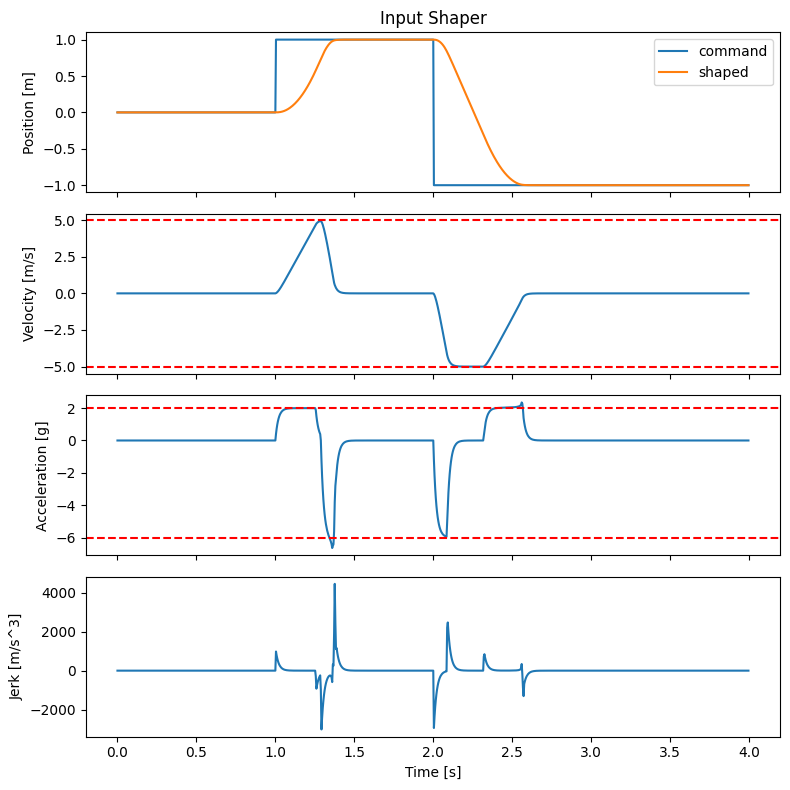

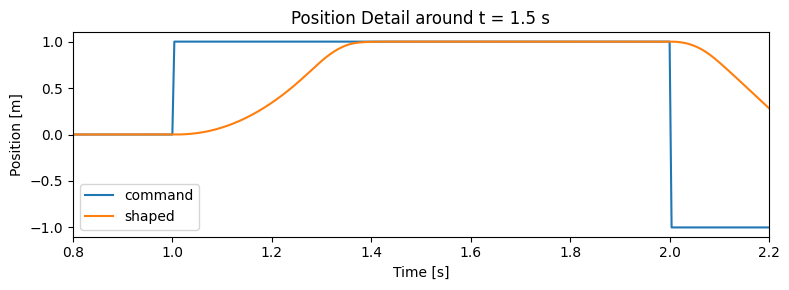

In [ ]:
import numpy    
import matplotlib.pyplot as plt
dt = 1.0/250.0

g = 9.81
num_samples = int(4/dt)


x_command = []

for n in range(num_samples):

    t = n*dt

    if t > 2.0:
        x = -1.0
    elif t > 1.0:
        x = 1.0
    else:
        x = 0.0

    
    
    x_command.append(x)


x_command = numpy.array(x_command)

# positive constrains
vp_max = 5.0 #max velocity
ap_max = 2*g #max acceleration

# negative constrains
vn_max = -1*vp_max
an_max = -3*ap_max




class ShaperVel:
    def __init__(self, v_max,  dt=0.01):
        self.v_max = float(v_max)
        self.dt = float(dt)

        self.x_curr = 0.0

    def step(self, x_target):
      
        vel_req = (x_target - self.x_curr)/self.dt
        vel_req = numpy.clip(vel_req, -self.v_max, self.v_max)

        self.x_curr += vel_req*self.dt
            
        return self.x_curr

    def __call__(self, x_target):
        return self.step(x_target)  
    

class ShaperVelAcc:
    def __init__(self, vn_max, vp_max, an_max, ap_max, alpha = 0.3, dt=0.01):

        self.vn_max = float(vn_max)
        self.vp_max = float(vp_max)
        self.an_max = float(an_max)
        self.ap_max = float(ap_max)

        self.dt = float(dt)

        self.alpha = alpha

        self.x = 0.0
        self.v = 0.0
        self.a = 0.0

        self.x_fil = 0.0

    def step(self, x_target):

        dx = x_target - self.x

        # --- Braking-distance velocity limit ---
        # When moving positive and target is ahead: decel uses an_max (negative)
        # When moving positive and target is behind: must brake, decel uses an_max
        # v_brake_pos: max positive velocity from which we can still stop at x_target
        # v_brake_neg: max negative velocity (magnitude) from which we can stop at x_target

        # If we're ahead of target (dx < 0), positive velocity must be limited
        # to what an_max can bring to zero over distance |dx|:  v^2 / (2*|a|) <= |dx|
        # If we're behind target (dx > 0), negative velocity must be limited similarly.

        if dx > 0:
            # target is ahead: limit positive vel so we can brake with |an_max|
            v_brake_pos = numpy.sqrt(2.0 * abs(self.an_max) * dx)
            v_brake_neg = self.vn_max  # no limit needed in this direction
        elif dx < 0:
            # target is behind: limit negative vel so we can brake with ap_max
            v_brake_pos = self.vp_max  # no limit needed
            v_brake_neg = -numpy.sqrt(2.0 * self.ap_max * abs(dx))
        else:
            v_brake_pos = 0.0
            v_brake_neg = 0.0

        # Effective velocity bounds: intersection of kinematic limits and braking limits
        v_upper = min(self.vp_max, v_brake_pos)
        v_lower = max(self.vn_max, v_brake_neg)

        # requested velocity
        v_req = dx / self.dt
        v_req = numpy.clip(v_req, v_lower, v_upper)

        # requested acceleration
        a_req = (v_req - self.v) / self.dt
        self.a = numpy.clip(a_req, self.an_max, self.ap_max)

        # integrate acceleration
        self.v += self.a * self.dt
        self.v = numpy.clip(self.v, v_lower, v_upper)

        # integrate velocity
        self.x += self.v * self.dt  

        self.x_fil = (1.0 - self.alpha)*self.x_fil + self.alpha*self.x

        return self.x_fil



#shaper = ShaperVel(v_max, dt)
shaper = ShaperVelAcc(vn_max, vp_max, an_max, ap_max, 0.2, dt)


x_shaped = numpy.zeros(num_samples)
v_shaped = numpy.zeros(num_samples)
a_shaped = numpy.zeros(num_samples)
j_shaped = numpy.zeros(num_samples)

x_curr = 0.0

for n in range(num_samples):
    x_shaped[n] = shaper.step(x_command[n])


for n in range(num_samples):
    v_shaped[n] = (x_shaped[n] - x_shaped[n-1])/dt if n > 0 else 0.0
    a_shaped[n] = (v_shaped[n] - v_shaped[n-1])/dt if n > 0 else 0.0
    j_shaped[n] = (a_shaped[n] - a_shaped[n-1])/dt if n > 0 else 0.0



time_steps = dt*numpy.arange(num_samples)
fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

axes[0].plot(time_steps, x_command, label='command')
axes[0].plot(time_steps, x_shaped, label='shaped')
axes[0].set_ylabel('Position [m]')
axes[0].legend()
axes[0].set_title('Input Shaper')

axes[1].plot(time_steps, v_shaped)
axes[1].axhline(vp_max, color='r', ls='--', label='v_max')
axes[1].axhline(vn_max, color='r', ls='--')
axes[1].set_ylabel('Velocity [m/s]')
#axes[1].legend()

axes[2].plot(time_steps, a_shaped/g)
axes[2].axhline(ap_max/g, color='r', ls='--', label='a_max')
axes[2].axhline(an_max/g, color='r', ls='--')
axes[2].set_ylabel('Acceleration [g]')
#axes[2].legend()

axes[3].plot(time_steps, j_shaped)
axes[3].set_ylabel('Jerk [m/s^3]')
axes[3].set_xlabel('Time [s]')
#axes[3].legend()

plt.tight_layout()
plt.show()

# Detail plot around t = 1.5 s
fig2, ax2 = plt.subplots(figsize=(8, 3))
ax2.plot(time_steps, x_command, label='command')
ax2.plot(time_steps, x_shaped, label='shaped')
ax2.set_xlim(0.8, 2.2)
ax2.set_ylabel('Position [m]')
ax2.set_xlabel('Time [s]')
ax2.set_title('Position Detail around t = 1.5 s')
ax2.legend()
plt.tight_layout()
plt.show()